# Capítulo 4 — Vapor d'Água: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | Clausius–Clapeyron como EDO; gelo × líquido | `scipy.solve_ivp`, `MetPy` |
| 2 | carta psicrométrica: $r$ × $T$ com curvas de UR | NumPy |
| 3 | LCL exato × regra dos 125 m/°C; base de nuvem no dia | `MetPy` |
| 4 | água precipitável e a escala de 7 %/K | `MetPy` |

Exercícios numéricos N1–N4 no fim; soluções em `cap04_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

# constantes do Cap. 4 (Stull)
e0, T0 = 0.6113, 273.15      # kPa, K
Rv     = 461.0               # J kg-1 K-1
Lv, Ld = 2.5e6, 2.83e6       # J/kg (vaporização, deposição)
eps    = 0.622
print(f'L_v/R_v = {Lv/Rv:.0f} K (livro: 5423 K) | L_d/R_v = {Ld/Rv:.0f} K (livro: 6139 K)')

L_v/R_v = 5423 K (livro: 5423 K) | L_d/R_v = 6139 K (livro: 6139 K)


## Caso 1 — Clausius–Clapeyron: a EDO que faz o clima

$$\frac{de_s}{dT} = \frac{L\,e_s}{\Re_v T^2}$$

Integramos numericamente a partir de $(T_0, e_0)$ e comparamos com a fórmula do livro (que assume $L$ constante) e com o MetPy. Depois, o detalhe que alimenta o processo de Bergeron (Cap. 7): sobre **gelo** a curva é mais baixa que sobre **água super-resfriada**.

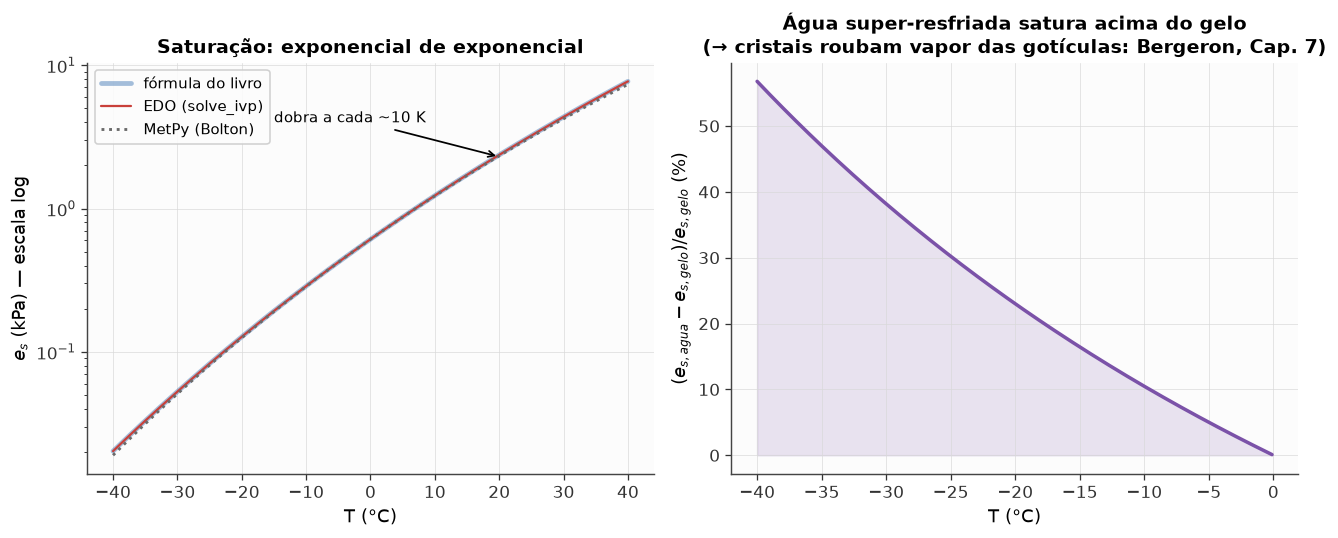

e_s(20 °C): EDO 2.361 | livro 2.361 | MetPy 2.328 kPa
máximo da diferença água–gelo: T = -40 °C


In [2]:
from metpy.units import units
import metpy.calc as mpcalc

T = np.linspace(-40, 40, 400) + 273.15

sol = solve_ivp(lambda TT, es: Lv*es/(Rv*TT**2), [T0, T[-1]], [e0],
                dense_output=True, rtol=1e-10)
sol_frio = solve_ivp(lambda TT, es: Lv*es/(Rv*TT**2), [T0, T[0]], [e0],
                     dense_output=True, rtol=1e-10)
es_edo = np.where(T >= T0, sol.sol(T)[0], sol_frio.sol(T)[0])
es_livro = e0*np.exp((Lv/Rv)*(1/T0 - 1/T))
es_gelo  = e0*np.exp((Ld/Rv)*(1/T0 - 1/T))
es_metpy = mpcalc.saturation_vapor_pressure(T*units.K).to('kPa').magnitude

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))
ax1.semilogy(T - 273.15, es_livro, color=CORES['azul'], lw=3, alpha=0.4,
             label='fórmula do livro')
ax1.semilogy(T - 273.15, es_edo, color=CORES['vermelho'], lw=1.4,
             label='EDO (solve_ivp)')
ax1.semilogy(T - 273.15, es_metpy, ':', color=CORES['cinza'], lw=1.8,
             label='MetPy (Bolton)')
ax1.annotate('dobra a cada ~10 K', xy=(20, 2.3), xytext=(-15, 4),
             fontsize=9.5, arrowprops=dict(arrowstyle='->', lw=1.1))
ax1.set(xlabel='T (°C)', ylabel='$e_s$ (kPa) — escala log',
        title='Saturação: exponencial de exponencial')
ax1.legend()

frio = T <= T0
ax2.plot(T[frio] - 273.15, (es_livro[frio] - es_gelo[frio])/es_gelo[frio]*100,
         color=CORES['roxo'])
ax2.fill_between(T[frio] - 273.15,
                 (es_livro[frio] - es_gelo[frio])/es_gelo[frio]*100,
                 0, color=CORES['roxo'], alpha=0.15)
ax2.set(xlabel='T (°C)', ylabel='$(e_{s,agua} - e_{s,gelo})/e_{s,gelo}$ (%)',
        title='Água super-resfriada satura acima do gelo\n(→ cristais roubam vapor das gotículas: Bergeron, Cap. 7)')
fig.tight_layout(); plt.show()

i20 = np.argmin(np.abs(T - 293.15))
print(f'e_s(20 °C): EDO {es_edo[i20]:.3f} | livro {es_livro[i20]:.3f} | '
      f'MetPy {es_metpy[i20]:.3f} kPa')
print(f'máximo da diferença água–gelo: T = '
      f'{T[frio][np.argmax((es_livro[frio]-es_gelo[frio])/es_gelo[frio])]-273.15:.0f} °C')

## Caso 2 — A carta psicrométrica: o mapa da umidade

$$r = \frac{\varepsilon\,e}{P - e},\qquad \mathrm{UR} = 100\,\frac{e}{e_s(T)}$$

Cada ponto $(T, r)$ é um estado do ar; as curvas de UR constante organizam o mapa. Ar que esfria anda para a esquerda com $r$ fixo — até bater na curva de 100 % (orvalho!).

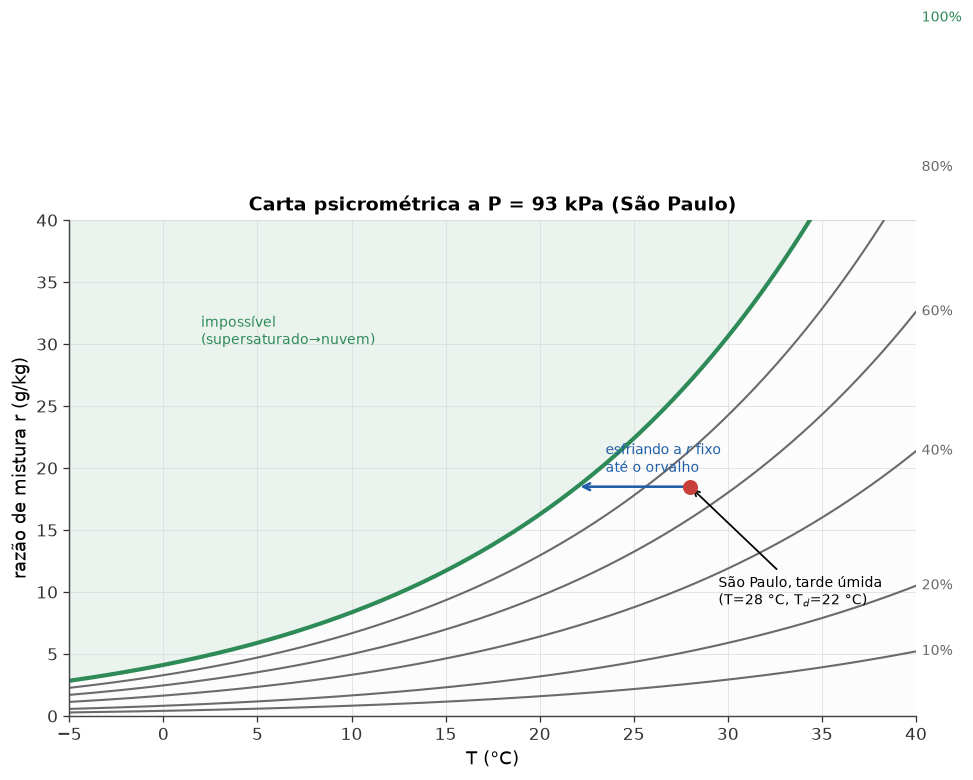

Ponto de exemplo: r = 18.5 g/kg, UR = 69%


In [3]:
P_sp = 93.0     # kPa — pressão típica de São Paulo (~800 m)

def es_kPa(T_C):
    TT = T_C + 273.15
    return e0*np.exp((Lv/Rv)*(1/T0 - 1/TT))

def r_gkg(T_C, UR):
    e = UR/100*es_kPa(T_C)
    return 1e3*eps*e/(P_sp - e)

T_C = np.linspace(-5, 40, 300)
fig, ax = plt.subplots(figsize=(9.5, 5.6))
for UR in [10, 20, 40, 60, 80, 100]:
    lw = 2.6 if UR == 100 else 1.3
    cor = CORES['verde'] if UR == 100 else CORES['cinza']
    ax.plot(T_C, r_gkg(T_C, UR), color=cor, lw=lw)
    ax.annotate(f'{UR}%', xy=(40.3, r_gkg(40, UR)), fontsize=8.5,
                color=cor, va='center', annotation_clip=False)
ax.fill_between(T_C, r_gkg(T_C, 100), 40, color=CORES['verde'], alpha=0.08)
ax.text(2, 30, 'impossível\n(supersaturado→nuvem)', fontsize=9,
        color=CORES['verde'])

# o dia úmido de São Paulo das notas: T=28 °C, Td=22 °C
T_ex, Td_ex = 28.0, 22.0
e_ex = es_kPa(Td_ex); r_ex = 1e3*eps*e_ex/(P_sp - e_ex)
ax.scatter([T_ex], [r_ex], s=70, color=CORES['vermelho'], zorder=5)
ax.annotate('São Paulo, tarde úmida\n(T=28 °C, T$_d$=22 °C)',
            xy=(T_ex, r_ex), xytext=(29.5, 9), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=1.1))
ax.annotate('', xy=(Td_ex, r_ex), xytext=(T_ex, r_ex),
            arrowprops=dict(arrowstyle='->', color=CORES['azul'], lw=1.6))
ax.text(23.5, r_ex + 1.2, 'esfriando a $r$ fixo\naté o orvalho', fontsize=8.5,
        color=CORES['azul'])
ax.set(xlim=(-5, 40), ylim=(0, 40),
       xlabel='T (°C)', ylabel='razão de mistura r (g/kg)',
       title=f'Carta psicrométrica a P = {P_sp:.0f} kPa (São Paulo)')
plt.show()
print(f'Ponto de exemplo: r = {r_ex:.1f} g/kg, '
      f'UR = {100*e_ex/es_kPa(T_ex):.0f}%')

## Caso 3 — LCL: a base da nuvem como higrômetro

$$z_{LCL} = 0{,}125\ \mathrm{km/°C}\,(T - T_d)$$

Comparamos a regra com o cálculo exato do MetPy e seguimos a base do cumulus ao longo de um dia de aquecimento ($T$ sobe, $T_d$ quase fixo).

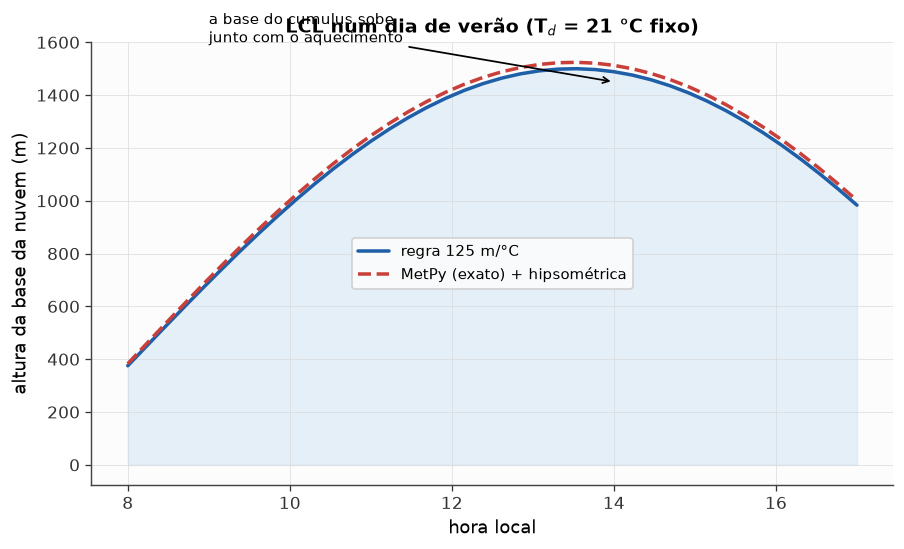

às 14 h: regra = 1489 m | exato = 1513 m (diferença 1.6%)


In [4]:
P_sfc = 93.0*units.kPa
Td_dia = 21.0
horas = np.linspace(8, 17, 40)
T_dia = 24 + 9*np.sin(np.pi*(horas - 8)/11)          # 24 → 33 °C

z_regra, z_exato = [], []
for T_h in T_dia:
    z_regra.append(125.0*(T_h - Td_dia))
    p_lcl, T_lcl = mpcalc.lcl(P_sfc, T_h*units.degC, Td_dia*units.degC)
    # altura pela hipsométrica (Cap. 1) com Tv média da camada
    Tv_m = 0.5*(T_h + T_lcl.to('degC').magnitude) + 273.15
    z_exato.append(287.0/9.8*Tv_m*np.log((P_sfc/p_lcl).magnitude))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(horas, np.array(z_regra), color=CORES['azul'],
        label='regra 125 m/°C')
ax.plot(horas, np.array(z_exato), '--', color=CORES['vermelho'],
        label='MetPy (exato) + hipsométrica')
ax.fill_between(horas, np.array(z_regra), color='#cfe3f5', alpha=0.5)
ax.annotate('a base do cumulus sobe\njunto com o aquecimento',
            xy=(14, 1450), xytext=(9, 1600), fontsize=9.5,
            arrowprops=dict(arrowstyle='->', lw=1.1))
ax.set(xlabel='hora local', ylabel='altura da base da nuvem (m)',
       title=f'LCL num dia de verão (T$_d$ = {Td_dia:.0f} °C fixo)')
ax.legend()
plt.show()
print(f'às 14 h: regra = {np.interp(14, horas, z_regra):.0f} m | '
      f'exato = {np.interp(14, horas, z_exato):.0f} m '
      f'(diferença {100*abs(np.interp(14, horas, z_regra)/np.interp(14, horas, z_exato)-1):.1f}%)')

## Caso 4 — Água precipitável: quanta chuva cabe no céu

$$W = \frac{1}{\rho_{liq}\,g}\int_0^{P_{sfc}} r\,dP$$

Calculamos $W$ da sondagem tropical do curso e de versões resfriadas com a **mesma umidade relativa** — a escala de Clausius–Clapeyron (~7 %/K) aparece na coluna inteira.

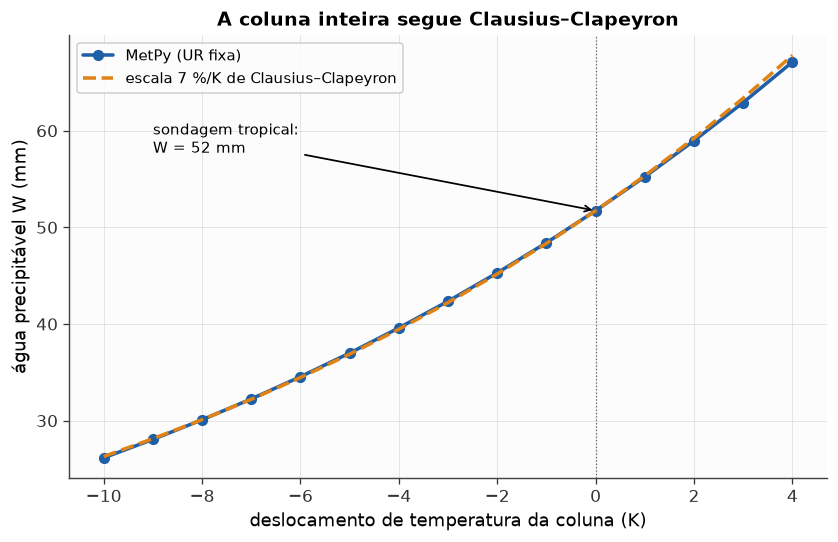

W(tropical) = 51.7 mm; resfriada 10 K: 26.2 mm; taxa média = 7.1 %/K


In [5]:
P_s  = np.array([1000, 925, 850, 700, 500, 400, 300, 250, 200]) * units.hPa
T_s  = np.array([27.0, 22.0, 17.5, 9.0, -6.5, -17.0, -32.0, -41.5, -53.0]) * units.degC
Td_s = np.array([22.0, 19.0, 15.0, 5.0, -14.0, -28.0, -45.0, -55.0, -68.0]) * units.degC

UR_s = mpcalc.relative_humidity_from_dewpoint(T_s, Td_s)

dTs = np.arange(-10, 4.1, 1.0)
Ws = []
for dT in dTs:
    T_mod  = (T_s.to('K').magnitude + dT)*units.K
    Td_mod = mpcalc.dewpoint_from_relative_humidity(T_mod, UR_s)
    Ws.append(mpcalc.precipitable_water(P_s, Td_mod).to('mm').magnitude)
Ws = np.array(Ws)
W0 = Ws[np.argmin(np.abs(dTs))]

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(dTs, Ws, 'o-', color=CORES['azul'], label='MetPy (UR fixa)')
ax.plot(dTs, W0*1.07**dTs, '--', color=CORES['laranja'],
        label='escala 7 %/K de Clausius–Clapeyron')
ax.axvline(0, color=CORES['cinza'], lw=0.8, ls=':')
ax.annotate(f'sondagem tropical:\nW = {W0:.0f} mm', xy=(0, W0),
            xytext=(-9, W0+6), fontsize=9.5,
            arrowprops=dict(arrowstyle='->', lw=1.1))
ax.set(xlabel='deslocamento de temperatura da coluna (K)',
       ylabel='água precipitável W (mm)',
       title='A coluna inteira segue Clausius–Clapeyron')
ax.legend()
plt.show()
print(f'W(tropical) = {W0:.1f} mm; resfriada 10 K: {Ws[0]:.1f} mm; '
      f'taxa média = {100*((W0/Ws[0])**(1/10)-1):.1f} %/K')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap04_solucoes.ipynb`**.

**N1** — Integre Clausius–Clapeyron com $L_v(T) = 2{,}501\times10^6 - 2370\,(T-273{,}15)$ J/kg e compare com a fórmula de $L_v$ constante entre −40 e +40 °C; trace o erro relativo.

**N2** — Psicrômetro digital: dado $T = 30$ °C, $T_w = 24$ °C, $P = 93$ kPa, resolva $r = r_s(T_w) - (C_p/L_v)(T - T_w)$ para $r$ e a UR (use `scipy.optimize.brentq` se necessário) e valide contra `mpcalc.relative_humidity_wet_psychrometric`.

**N3** — Para a sondagem do Caso 4, calcule o LCL exato de uma parcela de superfície e compare com a regra; depois refaça o Caso 3 para um dia mais seco ($T_d = 12$ °C).

**N4** — Trace $W$ × UR: recalcule a água precipitável da sondagem multiplicando a UR de todos os níveis por fatores 0,4…1,0 e discuta qual pesa mais em $W$: os níveis baixos ou os altos?

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*